In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import comb
from matplotlib import cm

In [2]:
SEED = 42
rng = np.random.default_rng(SEED)
n = 100  # number of flips (trials)
p = 0.5  # probability of head
thetas = np.linspace(0, 1, 100)  # range of theta values for plotting

Parameters of the binomial distribution:
* $n$ = number of trials [shape parameter]
* $p$ = probability of success [shape parameter]
* $k$ = number of successes observed (over the $n$ trials)

In my case, n is fixed, $p=\theta$ is my only parameter, and $k$ is the data I observe.
So I have the likelihood
$$L(\theta) = p({\rm data}|\theta) = p(K = k \mid n, p) = \binom{n}{k} p^k (1-p)^{n-k}, \quad k = 0, 1, \dots, n$$
So if I pass p as a vector arg, I'll have $L(\theta)$

In [3]:
flips = rng.choice([0, 1], size=n)  # 0 for tails, 1 for heads
k = flips.sum()  # number of heads observed

print(f'Observed k = {k} out of n = {n}')

Observed k = 52 out of n = 100


In [4]:
likelihood_dav = comb(n, k) * thetas**k * (1 - thetas) ** (n - k)  # just to check
samples = rng.binomial(n=n, p=p, size=n) / n  # sample from the binomial distribution

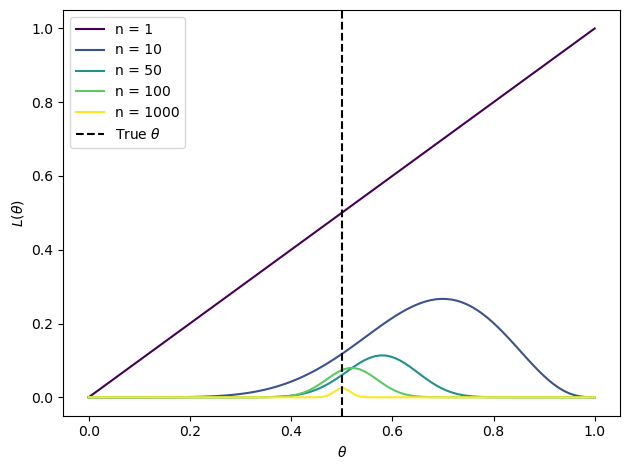

In [5]:
colors = cm.viridis(np.linspace(0, 1, 5))
for i, n in enumerate([1, 10, 50, 100, 1000]):
    flips = rng.choice([0, 1], size=n)  # 0 for tails, 1 for heads
    k = flips.sum()  # number of heads observed
    likelihood_scipy = stats.binom.pmf(k=k, n=n, p=thetas)

    # plt.plot(thetas, thetas, label='n = 1')
    # plt.plot(thetas, likelihood_dav, label=f'n = {n}')
    plt.plot(thetas, likelihood_scipy, label=f'n = {n}', color=colors[i])
    # plt.hist(samples, bins=25, density=True)

plt.xlabel(r'$\theta$')
plt.ylabel(r'$L(\theta)$')
plt.axvline(p, color='k', linestyle='--', label=r'True $\theta$')
plt.legend()
plt.tight_layout()

# plt.savefig(
#     '/Users/davidesciotti/Documents/Work/Lectures/Astrostatistics, 04:2026/Figs/coin_flip_like.png',
#     dpi=300,
# )

Removed no burn in


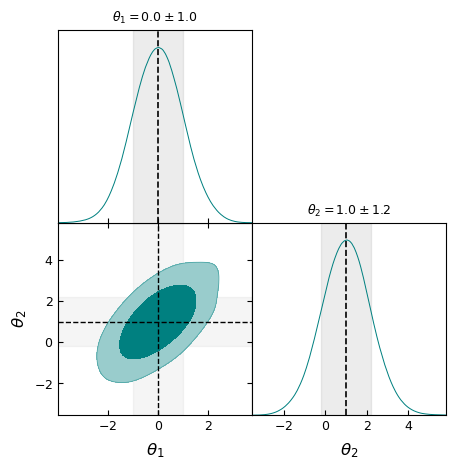

In [6]:
from getdist import MCSamples, plots

# --- Generate fake samples (replace with your own) ---
np.random.seed(42)
n = 10_000

# Correlated Gaussian: mean=[0,1], covariance with rho=0.7
mean = [0.0, 1.0]
cov = [[1.0, 0.7], [0.7, 1.4]]
samples = np.random.multivariate_normal(mean, cov, size=n)
fiducials = mean

# Sample estimates used for mean lines and 1sigma bands
means = np.mean(samples, axis=0)
stds = np.std(samples, axis=0, ddof=1)

# --- Wrap in MCSamples ---
names = ['theta_1', 'theta_2']
labels = [r'\theta_1', r'\theta_2']  # LaTeX labels shown on axes
mc = MCSamples(samples=samples, names=names, labels=labels)

# --- Triangle plot ---
g = plots.get_subplot_plotter(width_inch=5)
# g.triangle_plot(
#     [mc],
#     filled=True,  # filled 2-D contours
#     contour_colors=['teal'],
#     title_limit=1,
# )
g.triangle_plot(
    [mc],
    filled=True,  # filled 2-D contours
    contour_colors=['teal'],
    title_limit=1,
    contour_levels=[0.393, 0.865],  # show 68% and 95% contours
)

# Add mean lines and ±1σ shaded regions to all visible panels
npar = len(names)
for i in range(npar):
    for j in range(npar):
        ax = g.subplots[i, j]
        if ax is None:
            continue

        if i == j:
            ax.axvspan(
                means[j] - stds[j],
                means[j] + stds[j],
                color='grey',
                alpha=0.15,
                zorder=0,
            )
            ax.axvline(means[j], color='black', linestyle='--', linewidth=1.2)
        elif i > j:
            ax.axvspan(
                means[j] - stds[j],
                means[j] + stds[j],
                color='grey',
                alpha=0.08,
                zorder=0,
            )
            ax.axhspan(
                means[i] - stds[i],
                means[i] + stds[i],
                color='grey',
                alpha=0.08,
                zorder=0,
            )
            ax.axvline(means[j], color='black', linestyle='--', linewidth=1.0)
            ax.axhline(means[i], color='black', linestyle='--', linewidth=1.0)

# g.export(
#     '/Users/davidesciotti/Documents/Work/Lectures/Astrostatistics, 04:2026/Figs/triangle_plot.png',
#     dpi=300,
# )


Removed no burn in
[ 0.77964073 -0.77516665]
[0.62516193 0.63711759]


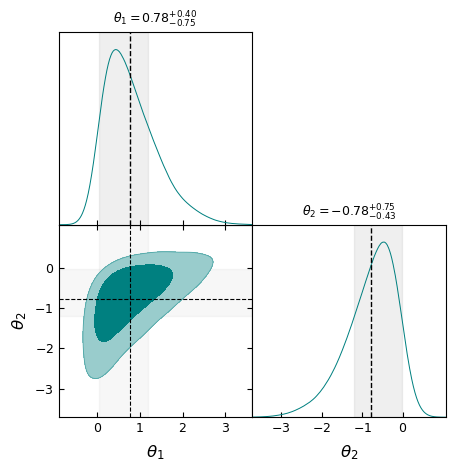

In [7]:
import numpy as np
from scipy.stats import skewnorm
from getdist import MCSamples, plots
import matplotlib.pyplot as plt


def make_samples(dist='banana', n=10_000, seed=42):
    """
    Generate 2D samples with various non-Gaussian shapes.
    dist: 'gaussian' | 'banana' | 'skewed' | 'bimodal' | 'log_normal'
    """
    np.random.seed(seed)

    if dist == 'gaussian':
        mean = [0.0, 1.0]
        cov = [[1.0, 0.7], [0.7, 1.4]]
        s = np.random.multivariate_normal(mean, cov, size=n)

    elif dist == 'banana':
        # Gaussian base, then bend one axis: classic parameter degeneracy
        cov = [[1.0, 0.0], [0.0, 0.5]]
        s = np.random.multivariate_normal([0.0, 0.0], cov, size=n)
        curvature = 0.5
        s[:, 1] = s[:, 1] + curvature * s[:, 0] ** 2 - curvature  # keep centred

    elif dist == 'skewed':
        # Skew-normal marginals + correlation via Gaussian copula
        alpha = [5.0, -4.0]  # skewness per parameter (positive = right tail)
        rho = 0.6
        cov = [[1.0, rho], [rho, 1.0]]
        z = np.random.multivariate_normal([0, 0], cov, size=n)
        from scipy.special import ndtr  # Phi(z)

        u = ndtr(z)  # shape (n, 2), uniform marginals
        s = np.column_stack([skewnorm.ppf(u[:, k], a=alpha[k]) for k in range(2)])

    elif dist == 'bimodal':
        # Mixture of two Gaussians
        n1 = n // 2
        s1 = np.random.multivariate_normal(
            [-1.5, -1.0], [[0.3, 0.1], [0.1, 0.3]], size=n1
        )
        s2 = np.random.multivariate_normal(
            [1.5, 1.0], [[0.4, -0.2], [-0.2, 0.3]], size=n - n1
        )
        s = np.vstack([s1, s2])

    elif dist == 'log_normal':
        # Both parameters log-normal, with correlation
        cov = [[0.5**2, 0.5 * 0.4 * 0.7], [0.5 * 0.4 * 0.7, 0.4**2]]
        z = np.random.multivariate_normal([0, 0], cov, size=n)
        s = np.exp(z)

    else:
        raise ValueError(f'Unknown dist: {dist}')

    return s


def triangle(samples_dict, contour_levels=[0.393, 0.865], fname=None):
    """
    Triangle plot for a dict {label: (n, 2) array}.
    Pass multiple entries to overlay chains.
    """
    names = ['theta_1', 'theta_2']
    labels = [r'\theta_1', r'\theta_2']
    colors = ['teal', 'crimson', 'darkorange', 'steelblue']

    mc_list = []
    for (label, s), col in zip(samples_dict.items(), colors):
        mc = MCSamples(
            samples=s,
            names=names,
            labels=labels,
            label=label,
            settings={'smooth_scale_2D': 0.4, 'smooth_scale_1D': 0.4},
        )
        mc_list.append(mc)

    g = plots.get_subplot_plotter(width_inch=5)
    g.triangle_plot(
        mc_list,
        filled=True,
        contour_colors=colors[: len(mc_list)],
        contour_levels=contour_levels,
        legend_labels=list(samples_dict.keys()) if len(mc_list) > 1 else None,
        title_limit=1,
    )

    # Mean lines + ±1σ bands
    for mc in mc_list:
        los, his, means = [], [], []
        stats = mc.getMargeStats()
        for i, name in enumerate(['theta_1', 'theta_2']):
            par = stats.parWithName(name)
            los.append(par.limits[0].lower)
            his.append(par.limits[0].upper)
            means.append(par.mean)

        # s     = mc.samples
        # means = s.mean(axis=0)
        # stds  = s.std(axis=0, ddof=1)
        for i in range(len(names)):
            for j in range(len(names)):
                ax = g.subplots[i, j]
                if ax is None:
                    continue
                if i == j:
                    ax.axvspan(los[j], his[j], color='grey', alpha=0.12, zorder=0)
                    ax.axvline(means[j], color='black', ls='--', lw=1.0)
                elif i > j:
                    ax.axvspan(los[j], his[j], color='grey', alpha=0.06, zorder=0)
                    ax.axhspan(los[i], his[i], color='grey', alpha=0.06, zorder=0)
                    ax.axvline(means[j], color='black', ls='--', lw=0.8)
                    ax.axhline(means[i], color='black', ls='--', lw=0.8)

    if fname:
        g.export(fname, dpi=150)
    return g, mc_list


# --- Usage examples ---

# Single shape
g, mc_list = triangle({'skewed': make_samples('skewed')}, fname='triangle_skewed.png')

mc_banana = mc_list[0]
print(mc_banana.getMeans())
print(np.sqrt(mc_banana.getVars()))

# Overlay two chains
# triangle(
#     {'bimodal': make_samples('bimodal'),
#      'Banana':   make_samples('banana')},
#     fname='triangle_overlay.png',
# )

# g.export(
#     '/Users/davidesciotti/Documents/Work/Lectures/Astrostatistics, 04:2026/Figs/triangle_plot_skewed.png',
#     dpi=300,
# )


In [9]:
az.__version__

'1.0.0'

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import arviz as az
from getdist import loadMCSamples

# ! 1. Load chains
chain_root = '/Users/davidesciotti/Documents/Work/Code/misc/archive/Exercise Matteo Euclid School 2022/chains_dav/good_mcmc'

samples = loadMCSamples(chain_root, no_cache=True)
param_names = [p.name for p in samples.paramNames.names]

# getSeparateChains() returns one MCSamples object per chain file
separate    = samples.getSeparateChains()
n_chains    = len(separate)
chain_arrays = [ch.samples for ch in separate]  # each: (N_steps, n_params)

min_len = min(arr.shape[0] for arr in chain_arrays)
stacked = np.stack([arr[:min_len] for arr in chain_arrays], axis=0)
# stacked shape: (M, N, n_params)

# ── 3. Build ArviZ InferenceData and plot traces ─────────────────────────────
import xarray as xr

dataset = xr.Dataset(
    {name: (["chain", "draw"], stacked[:, :, i])
     for i, name in enumerate(param_names)}
)
idata = az.InferenceData(posterior=dataset)

axes = az.plot_trace(idata, compact=False, figsize=(12, 3 * len(param_names)))
plt.suptitle('Trace plots', y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig('trace_plots.png', dpi=150, bbox_inches='tight')
plt.close()
print('Saved trace_plots.png')


# ── 4. R-1 vs step index ─────────────────────────────────────────────────────
def gelman_rubin_minus1(chains):
    """
    chains: ndarray of shape (M, N, P)
    Returns R-1 for each of the P parameters.
    """
    M, N, P = chains.shape
    theta_c = chains.mean(axis=1)  # (M, P)  — per-chain means
    theta_hat = theta_c.mean(axis=0)  # (P,)    — grand mean

    B = N / (M - 1) * ((theta_c - theta_hat) ** 2).sum(axis=0)  # (P,)
    W = (((chains - theta_c[:, None, :]) ** 2).sum(axis=1) / (N - 1)).mean(
        axis=0
    )  # (P,)

    V = (N - 1) / N * W + B / N * (1 + 1 / M)
    return V / W - 1


# Compute R-1 at ~200 evenly spaced step indices (starting after a minimum burn-in)
step_min = max(50, min_len // 20)
step_indices = np.unique(np.linspace(step_min, min_len, 200, dtype=int))
R_minus_1 = np.array([gelman_rubin_minus1(stacked[:, :s, :]) for s in step_indices])
# shape: (n_step_indices, n_params)

fig, ax = plt.subplots(figsize=(10, 4))
for i, name in enumerate(param_names):
    ax.plot(step_indices, R_minus_1[:, i], lw=1.2, label=name)
ax.axhline(0.01, color='k', ls='--', lw=1, label=r'$R-1 = 0.01$')
ax.set_xlabel('Step index (accepted steps)')
ax.set_ylabel(r'$R - 1$')
ax.set_yscale('log')
ax.set_title('Gelman-Rubin convergence diagnostic')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig('gelman_rubin.png', dpi=150, bbox_inches='tight')
plt.close()
print('Saved gelman_rubin.png')

/Users/davidesciotti/Documents/Work/Code/misc/archive/Exercise Matteo Euclid School 2022/chains_dav/good_mcmc.1.txt
/Users/davidesciotti/Documents/Work/Code/misc/archive/Exercise Matteo Euclid School 2022/chains_dav/good_mcmc.2.txt
/Users/davidesciotti/Documents/Work/Code/misc/archive/Exercise Matteo Euclid School 2022/chains_dav/good_mcmc.3.txt
/Users/davidesciotti/Documents/Work/Code/misc/archive/Exercise Matteo Euclid School 2022/chains_dav/good_mcmc.4.txt
Removed no burn in


AttributeError: module 'arviz' has no attribute 'InferenceData'

Saved trace_plots.png


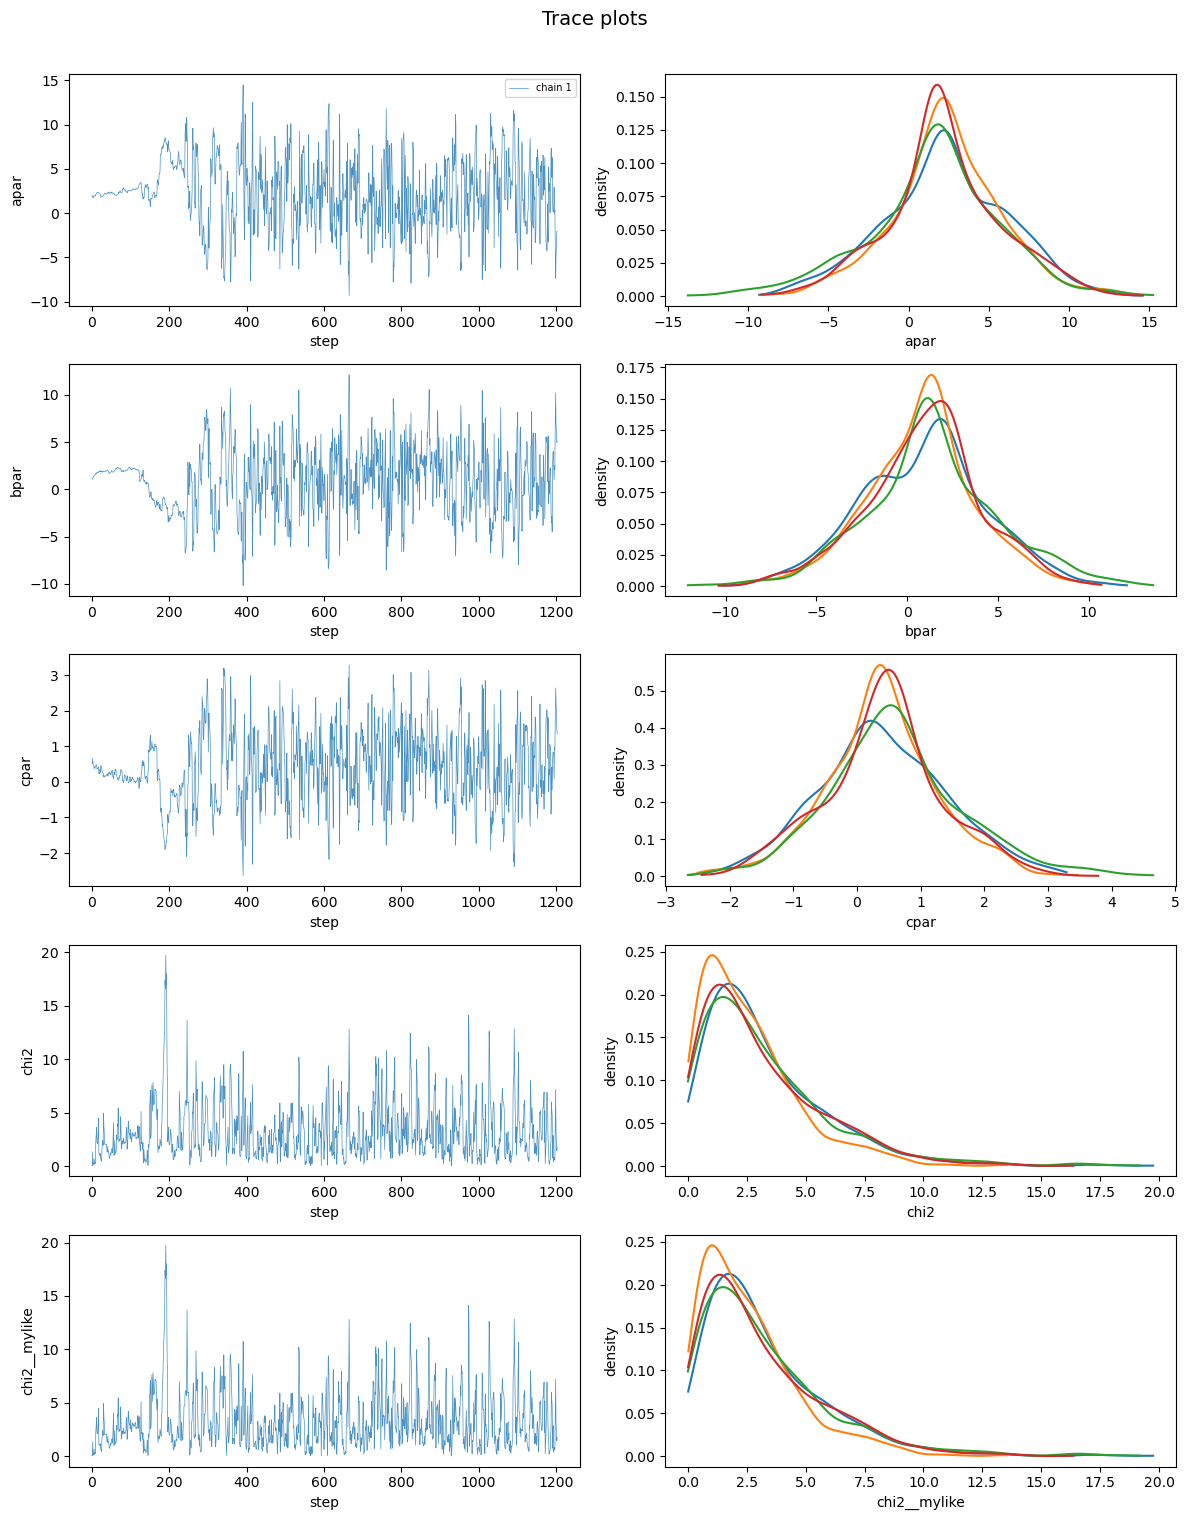

In [ ]:
import matplotlib.pyplot as plt

n_params = len(param_names)
fig, axes = plt.subplots(n_params, 2, figsize=(12, 3 * n_params))
if n_params == 1:
    axes = axes[np.newaxis, :]

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for p, name in enumerate(param_names):
    # ── left: trace ──────────────────────────────────────────────────────
    for c in range(1):
        axes[p, 0].plot(stacked[c, :, p], lw=0.5, alpha=0.8,
                        color=colors[c % len(colors)], label=f'chain {c+1}')
    axes[p, 0].set_ylabel(name)
    axes[p, 0].set_xlabel('step')
    if p == 0:
        axes[p, 0].legend(fontsize=7, ncol=n_chains)

    # ── right: marginal KDE ───────────────────────────────────────────────
    for c in range(n_chains):
        from scipy.stats import gaussian_kde
        vals = stacked[c, :, p]
        kde  = gaussian_kde(vals)
        xs   = np.linspace(vals.min(), vals.max(), 200)
        axes[p, 1].plot(xs, kde(xs), lw=1.5,
                        color=colors[c % len(colors)])
    axes[p, 1].set_xlabel(name)
    axes[p, 1].set_ylabel('density')

plt.suptitle('Trace plots', y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig('trace_plots.png', dpi=150, bbox_inches='tight')
print('Saved trace_plots.png')